**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Production economy and CO2 taxation](#toc1_)    
- 2. [Problem 2: Career choice model](#toc2_)    
- 3. [Problem 3: Barycentric interpolation](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [57]:
# Write your code here
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

%load_ext autoreload
%autoreload 2
from CareerChoice import CareerClass
from ProductionCO2Class import ProductionCO2Class
from barycentric_interpolation import barycentric_interpolation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. <a id='toc1_'></a>[Problem 1: Production economy and CO2 taxation](#toc0_)

Consider a production economy with two firms indexed by $j \in \{1,2\}$. Each produce its own good. They solve

$$
\begin{align*}
\max_{y_{j}}\pi_{j}&=p_{j}y_{j}-w_{j}\ell_{j}\\\text{s.t.}\;&y_{j}=A\ell_{j}^{\gamma}.
\end{align*}
$$

Optimal firm behavior is

$$
\begin{align*}
\ell_{j}^{\star}(w,p_{j})&=\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}} \\
y_{j}^{\star}(w,p_{j})&=A\left(\ell_{j}^{\star}(w,p_{j})\right)^{\gamma}
\end{align*}
$$

The implied profits are

$$
\pi_{j}^*(w,p_{j})=\frac{1-\gamma}{\gamma}w\cdot\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}}
$$

A single consumer supplies labor, and consumes the goods the firms produce. She also recieves the implied profits of the firm.<br>
She solves:

$$
\begin{align*}
U(p_1,p_2,w,\tau,T) = \max_{c_{1},c_{2},\ell} & \log(c_{1}^{\alpha}c_{2}^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} \\
\text{s.t.}\,\,\,&p_{1}c_{1}+(p_{2}+\tau)c_{2}=w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})
\end{align*}
$$

where $\tau$ is a tax and $T$ is lump-sum transfer. <br>
For a given $\ell$, it can be shown that optimal behavior is

$$
\begin{align*}
c_{1}(\ell)&=\alpha\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{1}} \\
c_{2}(\ell)&=(1-\alpha)\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{2}+\tau} \\
\end{align*}
$$
Such that optimal behavior is:
$$
\ell^* = \underset{\ell}{\arg\max} \log(\left(c_{1}(\ell)\right)^{\alpha}\cdot \left(c_{2}(\ell)\right)^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} 
$$
With optimal consumption:
$$
\begin{align*}
c_1^*=c_{1}(\ell^*) \\
c_2^*=c_{2}(\ell^*)\\
\end{align*}
$$


The government chooses $\tau$ and balances its budget so $T=\tau c_2^*$. We initially set $\tau,T=0$.

Market clearing requires:

1. Labor market: $\ell^* = \ell_1^* + \ell_2^*$
1. Good market 1: $c_1^* = y_1^*$
1. Good market 2: $c_2^* = y_2^*$


**Question 1:** Check market clearing conditions for $p_1$ in `linspace(0.1,2.0,10)` and $p_2$ in `linspace(0.1,2.0,10)`. We choose $w=1$ as numeraire.
__________________________________________________________________________________________
**Answer**

In [58]:
"""
All the relevant code for answering problem 1 is contained in the 'ProductionCO2Class', which is initialized below
"""

model = ProductionCO2Class()

In [59]:
"""
The market clearing conditions for the price vectors are found with a nested loop of different price combinations
"""

for p1 in np.linspace(0.1,2.0,10):
    for p2 in np.linspace(0.1,2.0,10):
        model.evaluate_equilibrium([p1,p2], do_print=True)

For p1=0.1000, p2=0.1000
Market clearing errors are:
Good1: 2.896964
Good2: 6.826250
Labor market: 0.972321
------------------------------------
For p1=0.1000, p2=0.3111
Market clearing errors are:
Good1: 2.834493
Good2: 2.007814
Labor market: 0.908103
------------------------------------
For p1=0.1000, p2=0.5222
Market clearing errors are:
Good1: 2.851377
Good2: 1.035249
Labor market: 0.825768
------------------------------------
For p1=0.1000, p2=0.7333
Market clearing errors are:
Good1: 2.941683
Good2: 0.585232
Labor market: 0.723339
------------------------------------
For p1=0.1000, p2=0.9444
Market clearing errors are:
Good1: 3.102266
Good2: 0.306573
Labor market: 0.599768
------------------------------------
For p1=0.1000, p2=1.1556
Market clearing errors are:
Good1: 3.332049
Good2: 0.105136
Labor market: 0.454695
------------------------------------
For p1=0.1000, p2=1.3667
Market clearing errors are:
Good1: 3.631225
Good2: -0.054831
Labor market: 0.288186
---------------------

__________________________________________________________________________________________

**Question 2:** Find the equilibrium prices $p_1$ and $p_2$.<br>
*Hint: you can use Walras' law to only check 2 of the market clearings*
__________________________________________________________________________________________
**Answer**

In [60]:
"""
The equilibrium prices are found by minimizing the absolute sum of market clearing errors
"""

model.find_prices(do_print=True)

For p1=0.9349, p2=1.4281
Market clearing errors are:
Good1: 0.000017
Good2: 0.000014
Labor market: 0.000036
------------------------------------


__________________________________________________________________________________________

Assume the government care about the social welfare function:

$$
SWF = U - \kappa y_2^*
$$

Here $\kappa$ measures the social cost of carbon emitted by the production of $y_2$ in equilibrium.

**Question 3:** What values of $\tau$ and (implied) $T$ should the government choose to maximize $SWF$?
__________________________________________________________________________________________
**Answer**

In [61]:
"""
The optimal tau and T are found by optimizing the social welfare function
"""

model.find_optimal_tau()

Evaluating social welfare function at tau=0.3820
SWF=-0.70
Evaluating social welfare function at tau=0.6180
SWF=-0.70
Evaluating social welfare function at tau=0.2361
SWF=-0.65
Evaluating social welfare function at tau=0.1459
SWF=-0.66
Evaluating social welfare function at tau=0.2260
SWF=-0.67
Evaluating social welfare function at tau=0.2918
SWF=-0.67
Evaluating social welfare function at tau=0.2574
SWF=-0.67
Evaluating social welfare function at tau=0.2442
SWF=-0.67
Evaluating social welfare function at tau=0.2322
SWF=-0.67
Evaluating social welfare function at tau=0.2392
SWF=-0.67
Evaluating social welfare function at tau=0.2346
SWF=-0.67
Evaluating social welfare function at tau=0.2373
SWF=-0.67
Evaluating social welfare function at tau=0.2355
SWF=-0.67
Evaluating social welfare function at tau=0.2365
SWF=-0.67
Evaluating social welfare function at tau=0.2359
SWF=-0.67
Evaluating social welfare function at tau=0.2362
SWF=-0.67
Evaluating social welfare function at tau=0.2360
SWF=-0.

__________________________________________________________________________________________

## 2. <a id='toc2_'></a>[Problem 2: Career choice model](#toc0_)

Consider a graduate $i$ making a choice between entering $J$ different career tracks. <br>
Entering career $j$ yields utility $u^k_{ij}$. This value is unknown to the graduate ex ante, but will ex post be: <br>
$$
    u_{i,j}^k = v_{j} + \epsilon_{i,j}^k
$$

They know that $\epsilon^k_{i,j}\sim \mathcal{N}(0,\sigma^2)$, but they do not observe $\epsilon^k_{i,j}$ before making their career choice. <br>

Consider the concrete case of $J=3$ with:
$$
\begin{align*}
    v_{1} &= 1 \\
    v_{2} &= 2 \\
    v_{3} &= 3
\end{align*}
$$

If the graduates know the values of $v_j$ and the distribution of $\epsilon_{i,j}^k$, they can calculate the expected utility of each career track using simulation: <br>
$$
    \mathbb{E}\left[ u^k_{i,j}\vert v_j \right] \approx v_j + \frac{1}{K}\sum_{k=1}^K \epsilon_{i,j}^k
$$

**Question 1:** Simulate and calculate expected utility and the average realised utility for $K=10000$ draws, for each career choice $j$.
__________________________________________________________________________________________
**Answer:**


In [62]:
# Initialize class
career = CareerClass()

# Parameters can be changed here if wanted
career.par.J = 3 # number of careers
career.par.N = 10 # number of graduates
career.par.K = 10000 # number of simulations
career.par.i = np.array([1,2,3,4,5,6,7,8,9,10])

career.par.F = np.arange(1,career.par.N+1,1) # number of friends in each career
career.par.sigma = 2 # standard deviation of the normal distribution

career.par.v = np.arange(1,career.par.J+1, 1) # utility of each career
career.par.c = 1 # cost of switching career

# set seed if wanted, for reproducability, each career does K different draws. 
seed = 2024

# run the method that answers the question
career.expec_and_avg_utility(seed=seed)

Career 1 - Expected Utility: 1.0154, Average Utility: 1.0154
Career 2 - Expected Utility: 2.0064, Average Utility: 2.0064
Career 3 - Expected Utility: 3.0030, Average Utility: 3.0030


Since the graduate knows the value of $v_j$, and we keep the random draws as the actual realizations of the noise term, there expected and average utility are obviously the same. It is not clear from the exam text if this is whats intended. We could easily modify the class method to use different draws for the realized noise terms, or unique independent draws for every one of the 10.000*3 draws, which would yield different results. 

Secondly, when $\# draws \to \infty$ the sample mean will converge to the distribution mean of 0, and since that is 0, the choice of career will be based on the career with the highest baseline utility absent of any noise, which in this case, is career 3. 
__________________________________________________________________________________________

The code for solving all subquestions of question 2 is found in CareerChoice.py, it also contains the relevant documentation for each line of code. 

In short, for question 2.1, we create arrays to store expected and average realized utilities. We loop over each career {1,2,3}, where each iteration does a draw of 10.000, $ \epsilon_{i,j}^k \sim \mathcal{N} (0,\sigma^2)$, values, then calculate the expected utility, as listed in the assignment text. We then calculate the average realized utility, using the same draws, since it is not clear from the text whether they should be different. We then print the results using another loop. Ofcourse these to utility types are identical due to simple logic, i.e. the average of the K-sum of a constant is the constant itself. 

Now consider a new scenario: Imagine that the graduate does not know $v_j$. The *only* prior information they have on the value of each job, comes from their $F_{i}$ friends that work in each career $j$. After talking with them, they know the average utility of their friends (which includes their friends' noise term), giving them the prior expecation: <br>
$$
\tilde{u}^k_{i,j}\left( F_{i}\right) = \frac{1}{F_{i}}\sum_{f=1}^{F_{i}} \left(v_{j} + \epsilon^k_{f,j}\right), \; \epsilon^k_{f,j}\sim \mathcal{N}(0,\sigma^2)
$$
For ease of notation consider that each graduate have $F_{i}=i$ friends in each career. <br>

For $K$ times do the following: <br>
1. For each person $i$ draw $J\cdot F_i$ values of $\epsilon_{f,j}^{k}$, and calculate the prior expected utility of each career track, $\tilde{u}^k_{i,j}\left( F_{i}\right)$. <br>
Also draw their own $J$ noise terms, $\epsilon_{i,j}^k$
1. Each person $i$ chooses the career track with the highest expected utility: $$j_i^{k*}= \arg\max_{j\in{1,2\dots,J}}\left\{ \tilde{u}^k_{i,j}\left( F_{i}\right)\right\} $$
1. Store the chosen careers: $j_i^{k*}$, the prior expectation of the value of their chosen career: $\tilde{u}^k_{i,j=j_i^{k*}}\left( F_{i}\right)$, and the realized value of their chosen career track: $u^k_{i,j=j_i^{k*}}=v_{j=j_i^{k*}}+\epsilon_{i,j=j_i^{k*}}^k$.

Chosen values will be: <br>
$i\in\left\{1,2\dots,N\right\}, N=10$ <br>
$F_i = i$<br>
So there are 10 graduates. The first has 1 friend in each career, the second has 2 friends, ... the tenth has 10 friends.

**Question 2:** Simulate and visualize: For each type of graduate, $i$, the share of graduates choosing each career, the average subjective expected utility of the graduates, and the average ex post realized utility given their choice. <br>
That is, calculate and visualize: <br>
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \mathbb{I}\left\{ j=j_i^{k*} \right\}  \;\forall j\in\left\{1,2,\dots,J\right\}
\end{align*}
$$
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \tilde{u}^k_{ij=j_i^{k*}}\left( F_{i}\right)
\end{align*}
$$
And 
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} u^k_{ij=j_i^{k*}} 
\end{align*}
$$
For each graduate $i$.

__________________________________________________________________________________________
**Answer:**

This method is deemed to long to explain intuitively. The documentation in the CareerChoice.py file is sufficient to understand the method. It could probaly be optimized, since it does a K*N (100.000) loop. We chose to do the graphs directly in the method, where we probaly should have created a new method for making the graphs, since they are very similar between this and the next question.

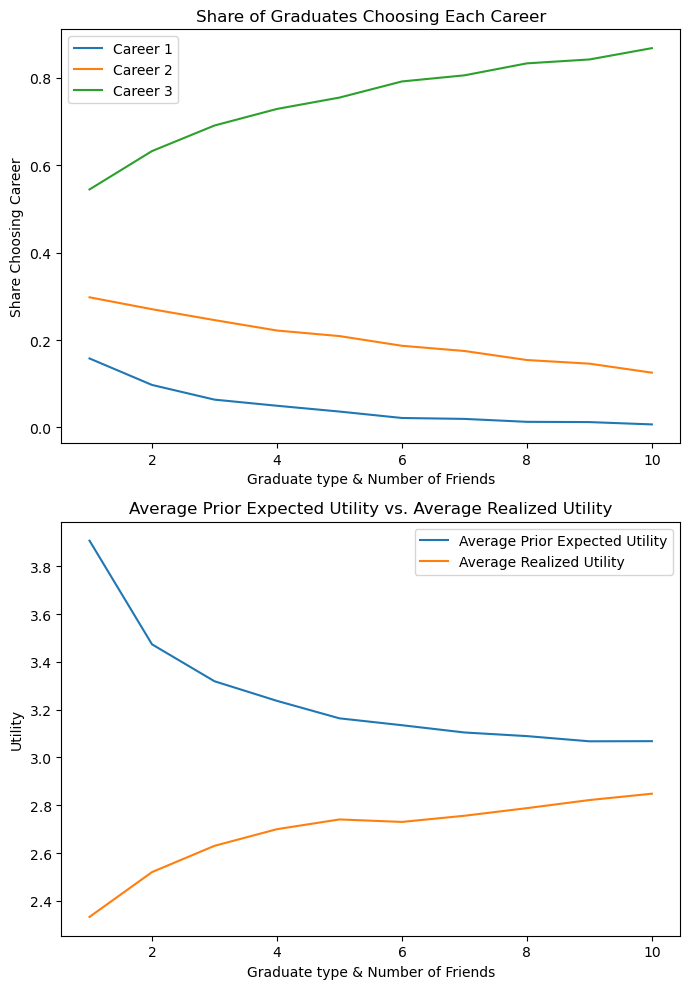

In [63]:
# This method does all the calculations and draws for question two and produced the required graphs.
# We also store key results for later use.
choices, average_prior_expected_utilities, average_realized_utilities, realized_utilities = career.simulate_career_choices(seed=seed)

**Share of graduates choosing each career**

The first graph shows the share of graduates choosing each career as number of friends increases. As expected most graduates choose career 3 since it has the highest intrinsic utility $(v_3 = 3 )$. In fact, the share of graduates choosing each career is ordered from most to least by the intrinsic utility of the career, which one would expect. 

When the number of friends in each career increases, the graduates can make better more informed desicions, as the noise will matter gradually less in their calculations. This means that more graduates will choose the *correct* career as friends-- thus information-- increases. 

**Average expected utility vs Average realized utility**

Similarly, the noise matters more when $F_i$ is small, where there is higher potential for overestimating their utility, this is why more people choose the lesser valuable careers at the starting point of the graph. This in turn means that their realized utility will be lower. As number of friends increase, their expected utility and realized utility will converge towards eachother, as seen in the graph.
__________________________________________________________________________________________

After a year of working in their career, the graduates learn $u^k_{ij}$ for their chosen job $j_i^{k*}$ perfectly. <br>
The can switch to one of the two remaining careers, for which they have the same prior as before, but it will now include a switching cost of $c$ which is known.
Their new priors can be written as: 
$$
\tilde{u}^{k,2}_{ij}\left( F_{i}\right) = \begin{cases}
            \tilde{u}^k_{ij}\left( F_{i}\right)-c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

We will set $c=1$.

Their realized utility will be: <br>
$$
u^{k,2}_{ij}= \begin{cases}
            u_{ij}^k -c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

**Question 3:** Following the same approach as in question 2, find the new optimal career choice for each $i$, $k$. Then for each $i$, calculate the average subjective expected utility from their new optimal career choice, and the ex post realized utility of that career. Also, for each $i$, calculate the share of graduates that chooses to switch careers, conditional on which career they chose in the first year. <br>
__________________________________________________________________________________________
**Answer**

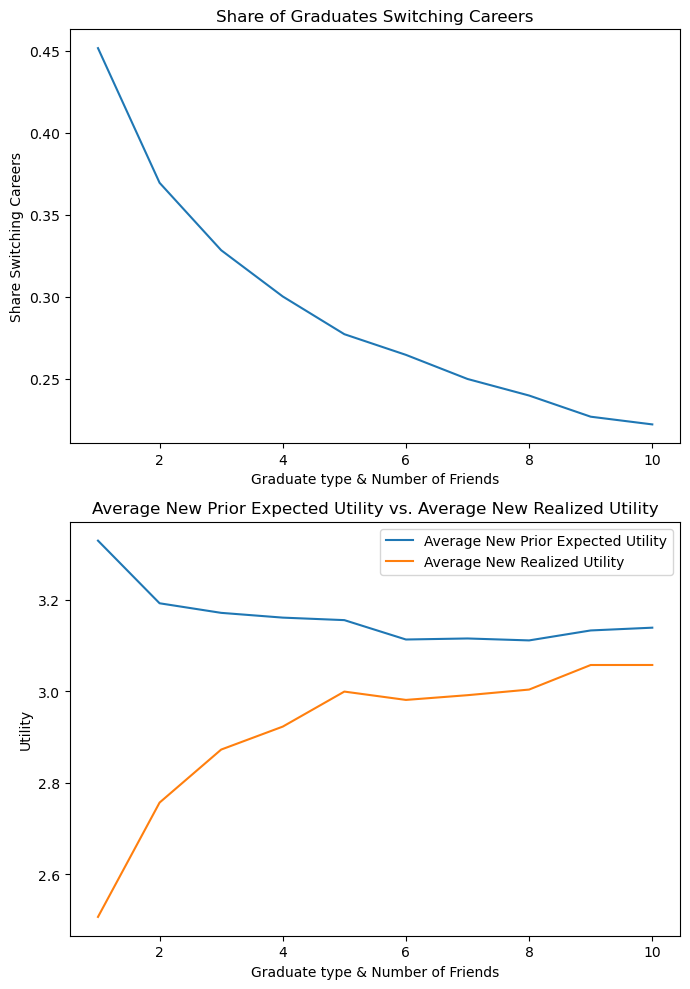

In [64]:
# we run the method that solves the question, we also unpack the results, though they arent used
# to not clutter the output. 
new_choices, average_new_prior_expected_utilities, average_new_realized_utilities, switch_decisions = career.simulate_switching_career(choices=choices, realized_utilities=realized_utilities, seed=seed)

As one would expect, there is a clear correlation between the share switching, and the shares not choosing career 3 in question 2.2. It is hard to comment specifically since there still is inherent randomness due to noise, and information not being clear such that as what career people chose from. We could analyze this further, but since comments in the first place isn't asked for in any of question 2 subquestions, we will simply comment on the results we have, which answers the questions. 

We can see that the bigger the negative gap between the average new expected utility and average new realized, the more switches are made which makes sense.
__________________________________________________________________________________________

## 3. <a id='toc3_'></a>[Problem 3: Barycentric interpolation](#toc0_)

**Problem:** We have a set of random points in the unit square,

$$
\mathcal{X} = \{(x_1,x_2)\,|\,x_1\sim\mathcal{U}(0,1),x_2\sim\mathcal{U}(0,1)\}.
$$

For these points, we know the value of some function $f(x_1,x_2)$,

$$
\mathcal{F} = \{f(x_1,x_2) \,|\, (x_1,x_2) \in \mathcal{X}\}.
$$

Now we want to approximate the value $f(y_1,y_2)$ for some  $y=(y_1,y_2)$, where $y_1\sim\mathcal{U}(0,1)$ and $y_2\sim\mathcal{U}(0,1)$.

**Building block I**

For an arbitrary triangle $ABC$ and a point $y$, define the so-called barycentric coordinates as:

$$
\begin{align*}
  r^{ABC}_1 &= \frac{(B_2-C_2)(y_1-C_1) + (C_1-B_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_2 &= \frac{(C_2-A_2)(y_1-C_1) + (A_1-C_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_3 &= 1 - r_1 - r_2.
\end{align*}
$$

If $r^{ABC}_1 \in [0,1]$, $r^{ABC}_2 \in [0,1]$, and $r^{ABC}_3 \in [0,1]$, then the point is inside the triangle.

We always have $y = r^{ABC}_1 A + r^{ABC}_2 B + r^{ABC}_3 C$.

**Building block II**

Define the following points:

$$
\begin{align*}
A&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}>y_{2}\\
B&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}<y_{2}\\
C&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}<y_{2}\\
D&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}>y_{2}.
\end{align*}
$$

**Algorithm:**

1. Compute $A$, $B$, $C$, and $D$. If not possible return `NaN`.
1. If $y$ is inside the triangle $ABC$ return $r^{ABC}_1 f(A) + r^{ABC}_2 f(B) + r^{ABC}_3 f(C)$.
1. If $y$ is inside the triangle $CDA$ return $r^{CDA}_1 f(C) + r^{CDA}_2 f(D) + r^{CDA}_3 f(A)$.
1. Return `NaN`.



**Sample:**

In [65]:
# Define barycentric interpolater as reference to class
interpolater = barycentric_interpolation()

# Generate random numbers
rng = np.random.default_rng(2024)

X = rng.uniform(size=(50,2))
y = rng.uniform(size=(2,))


**Questions 1:** Find $A$, $B$, $C$ and $D$. Illustrate these together with $X$, $y$ and the triangles $ABC$ and $CDA$.
__________________________________________________________________________________________
**Answer**

In [66]:
A,B,C,D = interpolater.find_ABCD(X,y)

------------------------------------------------------------------------------------------------------------------------
Finding coordinates for A,B,C and D
A,B,C and D coordinates have been succesfully found:
A: (0.26,0.44)
B: (0.21,0.27)
C: (0.10,0.28)
D: (0.21,0.44)
------------------------------------------------------------------------------------------------------------------------


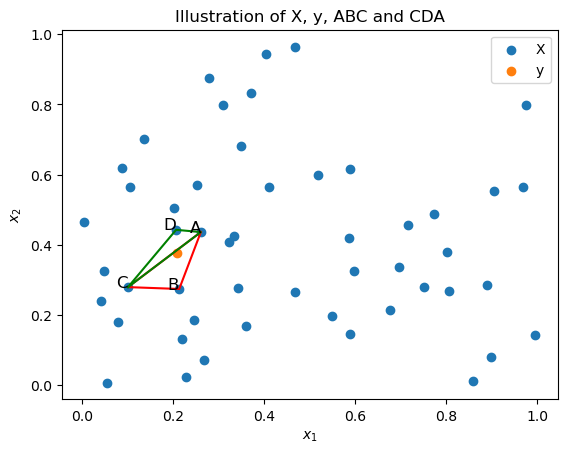

In [67]:
# Determine x1 and x2 values for the triangles
ABC_x1 = [A[0], B[0], C[0], A[0]]
ABC_x2 = [A[1], B[1], C[1], A[1]]

CDA_x1 = [C[0], D[0], A[0], C[0]]
CDA_x2 = [C[1], D[1], A[1], C[1]]

# Plot x1 and x2 values for both the set X and the soon-to-be interpolated set y as scatter plots
X_plot = plt.scatter(X[:,0],X[:,1])
y_plot = plt.scatter(y[0],y[1])

# Plot the triangles using the values
ABC = plt.plot(ABC_x1,ABC_x2,color='red')
CDA = plt.plot(CDA_x1,CDA_x2,color='green')

# Add labels to triangle vertices
plt.text(A[0], A[1], 'A', fontsize=12, ha='right')
plt.text(B[0], B[1], 'B', fontsize=12, ha='right')
plt.text(C[0], C[1], 'C', fontsize=12, ha='right')
plt.text(D[0], D[1], 'D', fontsize=12, ha='right')

# Add title, labels and legend
plt.title('Illustration of X, y, ABC and CDA')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend((X_plot,y_plot),("X", "y"))

__________________________________________________________________________________________

**Question 2:** Compute the barycentric coordinates of the point $y$ with respect to the triangles $ABC$ and $CDA$. Which triangle is $y$ located inside?
__________________________________________________________________________________________
**Answer**

In [68]:
if interpolater.compute_barycentric_coordinates(A,B,C,y)[1]:
    print(f'y is in triangle ABC')

------------------------------------------------------------------------------------------------------------------------
Finding barycentric coordinates for the triangle
Barycentric coordinates have been estimated:
r1ABC = 0.63
r2ABC = 0.07
r3ABC = 0.30
y is in the triangle
------------------------------------------------------------------------------------------------------------------------
y is in triangle ABC


__________________________________________________________________________________________

Now consider the function:
$$
f(x_1,x_2) = x_1 \cdot x_2
$$

In [69]:
f = lambda x: x[0]*x[1]
F = np.array([f(x) for x in X])

**Question 3:** Compute the approximation of $f(y)$ using the full algorithm. Compare with the true value.
__________________________________________________________________________________________
**Answer**

In [70]:
interpolater.barycentric_algorithm(X,y,f)

------------------------------------------------------------------------------------------------------------------------
Barycentric interpolation result for y = (0.21,0.38) ---> 0.08405     compared to f(y)=f(0.21,0.38) = 0.07896
Barycentric interpolation approximates f(y)=f(0.21,0.38) with 98.94% accuracy
------------------------------------------------------------------------------------------------------------------------


0.08405201731052576

__________________________________________________________________________________________

**Question 4:** Repeat question 3 for all points in the set $Y$.

In [71]:
Y = [(0.2,0.2),(0.8,0.2),(0.8,0.8),(0.8,0.2),(0.5,0.5)]

In [72]:
for y in Y:
    interpolater.barycentric_algorithm(X,y,f)

------------------------------------------------------------------------------------------------------------------------
Barycentric interpolation result for y = (0.20,0.20) ---> 0.04033     compared to f(y)=f(0.20,0.20) = 0.04000
Barycentric interpolation approximates f(y)=f(0.20,0.20) with 98.99% accuracy
------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------
Barycentric interpolation result for y = (0.80,0.20) ---> 0.15874     compared to f(y)=f(0.80,0.20) = 0.16000
Barycentric interpolation approximates f(y)=f(0.80,0.20) with 99.01% accuracy
------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------
A, B, C or D cant b

__________________________________________________________________________________________